--- Старт моделирования: Идеальное дно ---


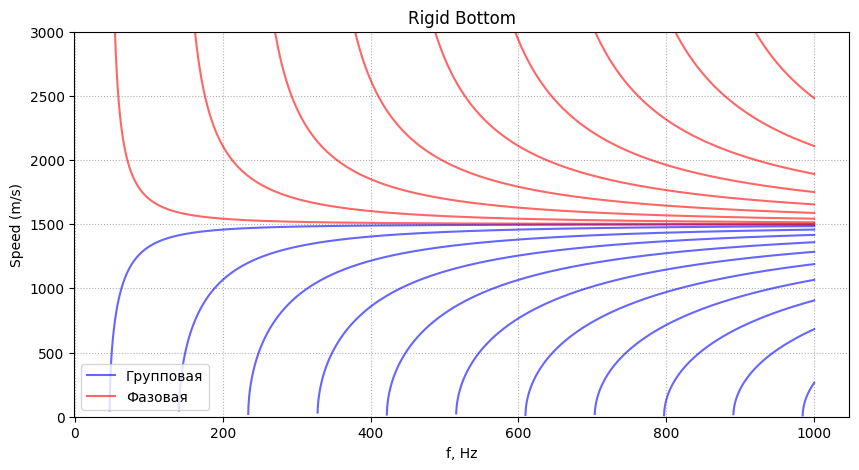

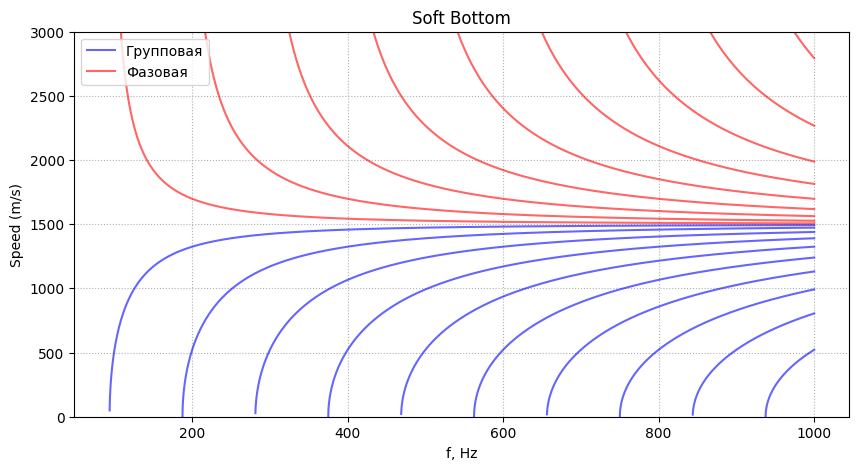


--- Старт моделирования: Волновод Пекериса ---
Расчет моды волновода Пекериса № 1...
Расчет моды волновода Пекериса № 2...
Расчет моды волновода Пекериса № 3...
Расчет моды волновода Пекериса № 4...
Расчет моды волновода Пекериса № 5...


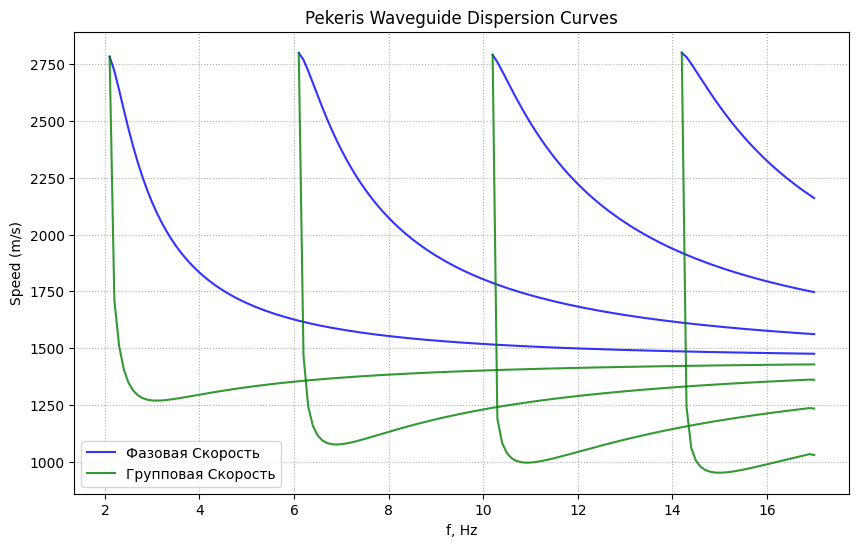

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import fmin

# =============================================================================
# 1. МАТЕМАТИЧЕСКИЕ ЯДРА МОДЕЛИРОВАНИЯ
# =============================================================================

def dispersion_ideal_bottom(m, c, f, H):
    """
    Аналог dispersion_ideal_bottom.m
    Расчет групповых и фазовых скоростей для идеального волновода.
    """
    # Предотвращаем деление на ноль при f = 0
    f_safe = np.where(f == 0, np.nan, f)
    
    with np.errstate(invalid='ignore'):
        # Выражения под корнем для абсолютно жесткого и мягкого дна
        term_rigid = 1 - ((m - 0.5) * (c / (2 * f_safe * H)))**2
        term_soft = 1 - (m * (c / (2 * f_safe * H)))**2
        
        # Если значение под корнем отрицательное (частота ниже критической) -> NaN
        c_group_rigid = c * np.sqrt(np.where(term_rigid < 0, np.nan, term_rigid))
        c_group_soft = c * np.sqrt(np.where(term_soft < 0, np.nan, term_soft))
    
    # Фазовые скорости
    c_phase_rigid = (c**2) / c_group_rigid
    c_phase_soft = (c**2) / c_group_soft
    
    return c_group_rigid, c_group_soft, c_phase_rigid, c_phase_soft


def esearch_half_space_function1(l, c0, c1, ro, f, h):
    """
    Аналог esearch_half_space_function1.m
    Поиск фазовых скоростей мод в волноводе Пекериса.
    """
    k0 = 2 * np.pi * f / c0  # Волновое число в воде
    n = c0 / c1             # Показатель преломления
    x0 = np.pi * l          # Начальное приближение
    
    # Сетка для быстрого поиска локального минимума
    xx = np.linspace(x0 - np.pi/2, x0 + np.pi/2, int(1e5))
    
    # Критическая частота для моды с номером l
    fcut = c0 * (l - 0.5) / (2 * h * np.sqrt(1 - n**2))
    
    c_phase = np.zeros(len(f))
    
    for num_f in range(len(f)):
        if f[num_f] <= fcut:
            c_phase[num_f] = 0
            continue
            
        nu = k0[num_f] * h * np.sqrt(1 - n**2)
        
        # Целевая функция. Добавление +0j форсирует работу с комплексными числами, 
        # исключая ошибки при отрицательном подкоренном выражении (как в MATLAB).
        def my_func(x):
            return np.abs(ro * x + np.tan(x) * np.sqrt(nu**2 - x**2 + 0j))
        
        # Грубый поиск минимума по сетке
        fx = my_func(xx)
        xx_min = xx[np.argmin(fx)]
        
        # Симплекс-метод Нелдера-Мида (прямой аналог fminsearch)
        sol_res = fmin(my_func, xx_min, xtol=1e-13, ftol=1e-13, disp=False, full_output=True)
        sol = sol_res[0][0]
        warnflag = sol_res[4] # 0 если сходимость успешна
        
        if warnflag != 0:
            print(f"Предупреждение: корень не найден для моды l={l} на частоте {f[num_f]:.1f} Гц")
            c_phase[num_f] = 0
            continue
            
        # Горизонтальное волновое число и фазовая скорость
        psil = np.sqrt((k0[num_f] * h)**2 - sol**2) / h
        c_phase[num_f] = 2 * np.pi * f[num_f] / psil
        
    return c_phase

# =============================================================================
# 2. СЦЕНАРИЙ РАСЧЕТА: ИДЕАЛЬНОЕ ДНО (Аналог groupeVel_Ideal.m)
# =============================================================================

def run_ideal_bottom_simulation():
    c = 1500
    H = 8
    modes = np.arange(1, 13)
    
    fmin, fmax, df = 1, 1000, 0.1
    freq = np.arange(fmin, fmax + df, df)
    
    c_gr_rigid = np.zeros((len(modes), len(freq)))
    c_gr_soft = np.zeros_like(c_gr_rigid)
    c_ph_rigid = np.zeros_like(c_gr_rigid)
    c_ph_soft = np.zeros_like(c_gr_rigid)
    
    for idx, m in enumerate(modes):
        cg_r, cg_s, cp_r, cp_s = dispersion_ideal_bottom(m, c, freq, H)
        c_gr_rigid[idx, :] = cg_r
        c_gr_soft[idx, :] = cg_s
        c_ph_rigid[idx, :] = cp_r
        c_ph_soft[idx, :] = cp_s
        
    # Замена значений ниже eps на NaN для чистых графиков без "хвостов" к нулю
    eps = np.finfo(float).eps
    for arr in [c_gr_rigid, c_gr_soft, c_ph_rigid, c_ph_soft]:
        arr[arr < eps] = np.nan
        
    # Визуализация абсолютно жесткого дна
    plt.figure(figsize=(10, 5))
    for i in range(len(modes)):
        plt.plot(freq, c_gr_rigid[i, :], 'b-', alpha=0.6, label='Групповая' if i == 0 else "")
        plt.plot(freq, c_ph_rigid[i, :], 'r-', alpha=0.6, label='Фазовая' if i == 0 else "")
    plt.title('Rigid Bottom')
    plt.ylabel('Speed (m/s)')
    plt.xlabel('f, Hz')
    plt.ylim(0, c * 2)
    plt.grid(True, linestyle=':')
    plt.legend()
    plt.show()
    
    # Визуализация абсолютно мягкого дна
    plt.figure(figsize=(10, 5))
    for i in range(len(modes)):
        plt.plot(freq, c_gr_soft[i, :], 'b-', alpha=0.6, label='Групповая' if i == 0 else "")
        plt.plot(freq, c_ph_soft[i, :], 'r-', alpha=0.6, label='Фазовая' if i == 0 else "")
    plt.title('Soft Bottom')
    plt.ylabel('Speed (m/s)')
    plt.xlabel('f, Hz')
    plt.ylim(0, c * 2)
    plt.grid(True, linestyle=':')
    plt.legend()
    plt.show()

# =============================================================================
# 3. СЦЕНАРИЙ РАСЧЕТА: ВОЛНОВОД ПЕКЕРИСА (Аналог groupeVel_Pekeris.m)
# =============================================================================

def run_pekeris_simulation():
    c = 1450
    c1 = 2800
    H = 209
    ro = 1.3
    modes = np.arange(1, 6)
    
    fmin, fmax, df = 0, 17, 0.1
    freq = np.arange(fmin, fmax + df, df)
    omega = 2 * np.pi * freq
    
    c_phase = np.zeros((len(modes), len(freq)))
    c_gr = np.zeros_like(c_phase)
    
    d_omega = omega[1] - omega[0]
    
    for idx, m in enumerate(modes):
        print(f"Расчет моды волновода Пекериса № {m}...")
        c_phase[idx, :] = esearch_half_space_function1(m, c, c1, ro, freq, H)
        c_phase_m = c_phase[idx, :]
        
        with np.errstate(divide='ignore', invalid='ignore'):
            # Численное дифференцирование (дифференциал фазовой скорости по частоте)
            grad_c_phase = np.gradient(c_phase_m, d_omega)
            c_gr_tmp = 1.0 / (1.0 / c_phase_m - (omega / (c_phase_m**2)) * grad_c_phase)
            
            # Перенос вычисленных значений групповой скорости для распространяющихся мод
            valid_idx = c_phase_m != 0
            c_gr[idx, valid_idx] = c_gr_tmp[valid_idx]
            
            # Обработка критических точек по логике оригинального кода MATLAB
            max_val = np.max(c_phase_m)
            max_idx = c_phase_m == max_val
            if max_val > 0:
                c_gr[idx, max_idx] = max_val
                
    eps = np.finfo(float).eps
    c_phase[c_phase < eps] = np.nan
    c_gr[c_gr < eps] = np.nan
    
    # Визуализация дисперсионных кривых Пекериса
    plt.figure(figsize=(10, 6))
    for i in range(len(modes)):
        plt.plot(freq, c_phase[i, :], 'b-', alpha=0.8, label='Фазовая Скорость' if i == 0 else "")
        plt.plot(freq, c_gr[i, :], 'g-', alpha=0.8, label='Групповая Скорость' if i == 0 else "")
    plt.title('Pekeris Waveguide Dispersion Curves')
    plt.ylabel('Speed (m/s)')
    plt.xlabel('f, Hz')
    plt.grid(True, linestyle=':')
    plt.legend()
    plt.show()

# =============================================================================
# ЗАПУСК ВСЕЙ СХЕМЫ МОДЕЛИРОВАНИЯ
# =============================================================================
if __name__ == '__main__':
    print("--- Старт моделирования: Идеальное дно ---")
    run_ideal_bottom_simulation()
    
    print("\n--- Старт моделирования: Волновод Пекериса ---")
    run_pekeris_simulation()

--- Старт моделирования: Идеальное дно ---


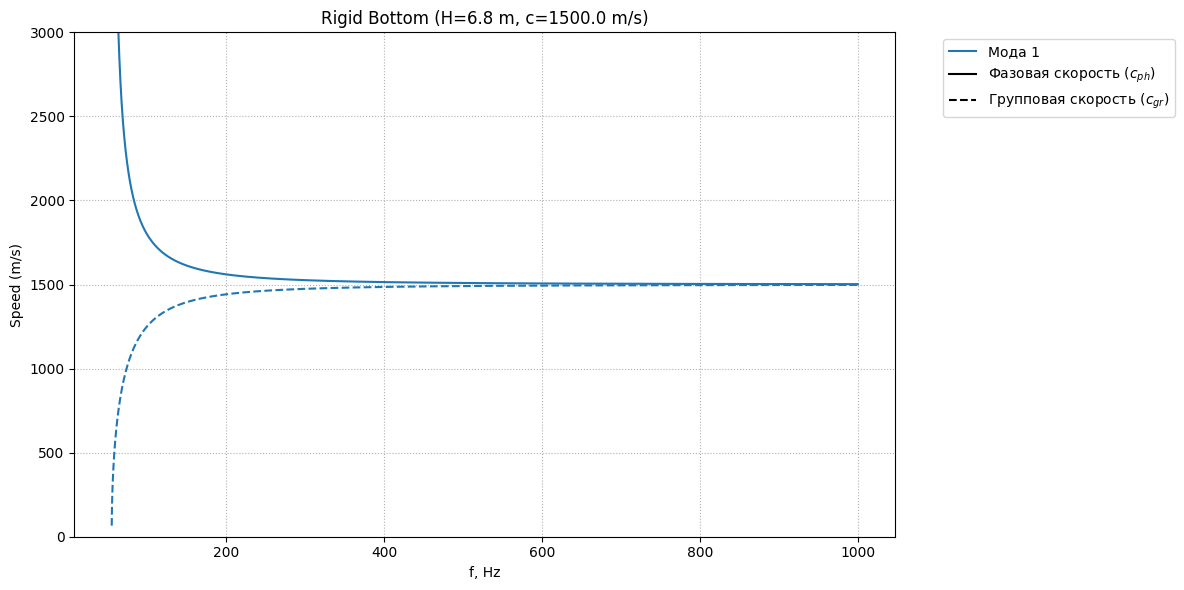


--- Старт моделирования: Волновод Пекериса ---
Расчет моды волновода Пекериса № 1...


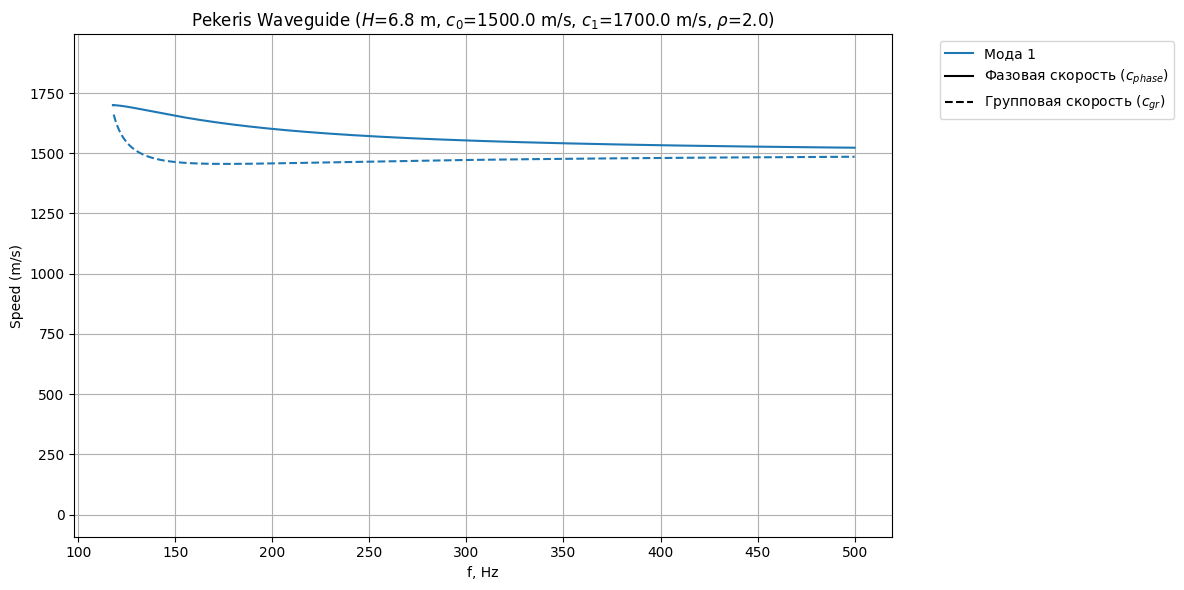

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import fmin
from matplotlib.lines import Line2D

# =============================================================================
# БЛОК НАСТРОЕК: ПАРАМЕТРЫ СРЕД И КОЛИЧЕСТВО МОД
# =============================================================================

# 1. Конфигурация для идеального волновода (Аналог groupeVel_Ideal.m)
IDEAL_CONFIG = {
    'modes': np.arange(1, 2),    # Номера мод (всего 12 мод)
    'c': 1500.0,                  # Скорость звука в воде, м/с
    'H': 6.8,                     # Глубина волновода, м
    'fmin': 1.0,                  # Нижняя граница частоты, Гц
    'fmax': 1000.0,                # Верхняя граница частоты, Гц
    'df': 0.1                     # Шаг по частоте, Гц
}

# 2. Конфигурация для волновода Пекериса (Аналог groupeVel_Pekeris.m)
PEKERIS_CONFIG = {
    'modes': np.arange(1, 2),     # Номера мод (всего 5 мод)
    'c0': 1500.0,                 # Скорость звука в воде, м/с
    'c1': 1700.0,                 # Скорость звука в жидком дне, м/с
    'H': 6.8,                     # Толщина слоя воды, м
    'ro': 2.0,                    # Отношение плотностей дна и воды (безразм.)
    'fmin': 117.0,                  # Нижняя граница частоты, Гц
    'fmax': 500.0,                 # Верхняя граница частоты, Гц
    'df': 0.1                     # Шаг по частоте, Гц
}


# =============================================================================
# МАТЕМАТИЧЕСКИЕ ЯДРА МОДЕЛИРОВАНИЯ
# =============================================================================

def dispersion_ideal_bottom(m, c, f, H):
    """Расчет скоростей для идеального волновода."""
    f_safe = np.where(f == 0, np.nan, f)
    with np.errstate(invalid='ignore'):
        term_rigid = 1 - ((m - 0.5) * (c / (2 * f_safe * H)))**2
        term_soft = 1 - (m * (c / (2 * f_safe * H)))**2
        
        c_group_rigid = c * np.sqrt(np.where(term_rigid < 0, np.nan, term_rigid))
        c_group_soft = c * np.sqrt(np.where(term_soft < 0, np.nan, term_soft))
    
    c_phase_rigid = (c**2) / c_group_rigid
    c_phase_soft = (c**2) / c_group_soft
    return c_group_rigid, c_group_soft, c_phase_rigid, c_phase_soft


def esearch_half_space_function1(l, c0, c1, ro, f, h):
    """Поиск фазовых скоростей мод в волноводе Пекериса (дисперсионное ур-е)."""
    k0 = 2 * np.pi * f / c0
    n = c0 / c1
    x0 = np.pi * l
    xx = np.linspace(x0 - np.pi/2, x0 + np.pi/2, int(1e5))
    fcut = c0 * (l - 0.5) / (2 * h * np.sqrt(1 - n**2))
    
    c_phase = np.zeros(len(f))
    for num_f in range(len(f)):
        if f[num_f] <= fcut:
            c_phase[num_f] = 0
            continue
            
        nu = k0[num_f] * h * np.sqrt(1 - n**2)
        my_func = lambda x: np.abs(ro * x + np.tan(x) * np.sqrt(nu**2 - x**2 + 0j))
        
        fx = my_func(xx)
        xx_min = xx[np.argmin(fx)]
        
        sol_res = fmin(my_func, xx_min, xtol=1e-13, ftol=1e-13, disp=False, full_output=True)
        sol = sol_res[0][0]
        
        if sol_res[4] != 0:
            c_phase[num_f] = 0
            continue
            
        psil = np.sqrt((k0[num_f] * h)**2 - sol**2) / h
        c_phase[num_f] = 2 * np.pi * f[num_f] / psil
    return c_phase


# =============================================================================
# СЦЕНАРИИ СИМУЛЯЦИЙ
# =============================================================================

def run_ideal_bottom_simulation(cfg):
    freq = np.arange(cfg['fmin'], cfg['fmax'] + cfg['df'], cfg['df'])
    modes = cfg['modes']
    
    c_gr_rigid = np.zeros((len(modes), len(freq)))
    c_gr_soft = np.zeros_like(c_gr_rigid)
    c_ph_rigid = np.zeros_like(c_gr_rigid)
    c_ph_soft = np.zeros_like(c_gr_rigid)
    
    for idx, m in enumerate(modes):
        cg_r, cg_s, cp_r, cp_s = dispersion_ideal_bottom(m, cfg['c'], freq, cfg['H'])
        c_gr_rigid[idx, :] = cg_r
        c_gr_soft[idx, :] = cg_s
        c_ph_rigid[idx, :] = cp_r
        c_ph_soft[idx, :] = cp_s
        
    for arr in [c_gr_rigid, c_gr_soft, c_ph_rigid, c_ph_soft]:
        arr[arr < np.finfo(float).eps] = np.nan
        
    speed_types_legend = [
        Line2D([0], [0], color='black', linestyle='-', label='Фазовая скорость ($c_{ph}$)'),
        Line2D([0], [0], color='black', linestyle='--', label='Групповая скорость ($c_{gr}$)')
    ]
    
    # График 1: Жесткое дно
    plt.figure(figsize=(12, 6))
    colors = plt.cm.tab20(np.linspace(0, 1, len(modes)))
    for idx, m in enumerate(modes):
        plt.plot(freq, c_ph_rigid[idx, :], linestyle='-', color=colors[idx], label=f'Мода {m}')
        plt.plot(freq, c_gr_rigid[idx, :], linestyle='--', color=colors[idx])
    plt.title(f"Rigid Bottom (H={cfg['H']} m, c={cfg['c']} m/s)")
    plt.ylabel('Speed (m/s)')
    plt.xlabel('f, Hz')
    plt.ylim(0, cfg['c'] * 2)
    plt.grid(True, linestyle=':')
    handles, _ = plt.gca().get_legend_handles_labels()
    plt.legend(handles=handles + speed_types_legend, bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()
    
    # График 2: Мягкое дно
    # plt.figure(figsize=(12, 6))
    # for idx, m in enumerate(modes):
    #     plt.plot(freq, c_ph_soft[idx, :], linestyle='-', color=colors[idx], label=f'Мода {m}')
    #     plt.plot(freq, c_gr_soft[idx, :], linestyle='--', color=colors[idx])
    # plt.title(f"Soft Bottom (H={cfg['H']} m, c={cfg['c']} m/s)")
    # plt.ylabel('Speed (m/s)')
    # plt.xlabel('f, Hz')
    # plt.ylim(0, cfg['c'] * 2)
    # plt.grid(True, linestyle=':')
    # handles, _ = plt.gca().get_legend_handles_labels()
    # plt.legend(handles=handles + speed_types_legend, bbox_to_anchor=(1.05, 1), loc='upper left')
    # plt.tight_layout()
    # plt.show()


def run_pekeris_simulation(cfg):
    freq = np.arange(cfg['fmin'], cfg['fmax'] + cfg['df'], cfg['df'])
    omega = 2 * np.pi * freq
    modes = cfg['modes']
    
    c_phase = np.zeros((len(modes), len(freq)))
    c_gr = np.zeros_like(c_phase)
    d_omega = omega[1] - omega[0]
    
    for idx, m in enumerate(modes):
        print(f"Расчет моды волновода Пекериса № {m}...")
        c_phase[idx, :] = esearch_half_space_function1(m, cfg['c0'], cfg['c1'], cfg['ro'], freq, cfg['H'])
        c_phase_m = c_phase[idx, :]
        
        with np.errstate(divide='ignore', invalid='ignore'):
            grad_c_phase = np.gradient(c_phase_m, d_omega)
            c_gr_tmp = 1.0 / (1.0 / c_phase_m - (omega / (c_phase_m**2)) * grad_c_phase)
            c_gr[idx, c_phase_m != 0] = c_gr_tmp[c_phase_m != 0]
            
            max_val = np.max(c_phase_m)
            if max_val > 0:
                c_gr[idx, c_phase_m == max_val] = max_val
                
    c_phase[c_phase < np.finfo(float).eps] = np.nan
    c_gr[c_gr < np.finfo(float).eps] = np.nan
    
    plt.figure(figsize=(12, 6))
    colors = plt.cm.tab10(np.linspace(0, 1, len(modes)))
    for idx, m in enumerate(modes):
        plt.plot(freq, c_phase[idx, :], linestyle='-', color=colors[idx], label=f'Мода {m}')
        plt.plot(freq[1:], c_gr[idx, 1:], linestyle='--', color=colors[idx])
    plt.title(f"Pekeris Waveguide ($H$={cfg['H']} m, $c_0$={cfg['c0']} m/s, $c_1$={cfg['c1']} m/s, $\\rho$={cfg['ro']})")
    plt.ylabel('Speed (m/s)')
    plt.xlabel('f, Hz')
    plt.grid(True)
    
    handles, _ = plt.gca().get_legend_handles_labels()
    speed_types_legend = [
        Line2D([0], [0], color='black', linestyle='-', label='Фазовая скорость ($c_{phase}$)'),
        Line2D([0], [0], color='black', linestyle='--', label='Групповая скорость ($c_{gr}$)')
    ]
    plt.legend(handles=handles + speed_types_legend, bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()


# =============================================================================
# ТОЧКА ВХОДА
# =============================================================================
if __name__ == '__main__':
    print("--- Старт моделирования: Идеальное дно ---")
    run_ideal_bottom_simulation(IDEAL_CONFIG)
    
    print("\n--- Старт моделирования: Волновод Пекериса ---")
    run_pekeris_simulation(PEKERIS_CONFIG)

--- Расчет дисперсии: Идеальное жесткое дно ---

--- Расчет дисперсии: Волновод Пекериса ---
Расчет моды волновода Пекериса № 1...

--- Визуализация совмещенного графика групповых скоростей ---


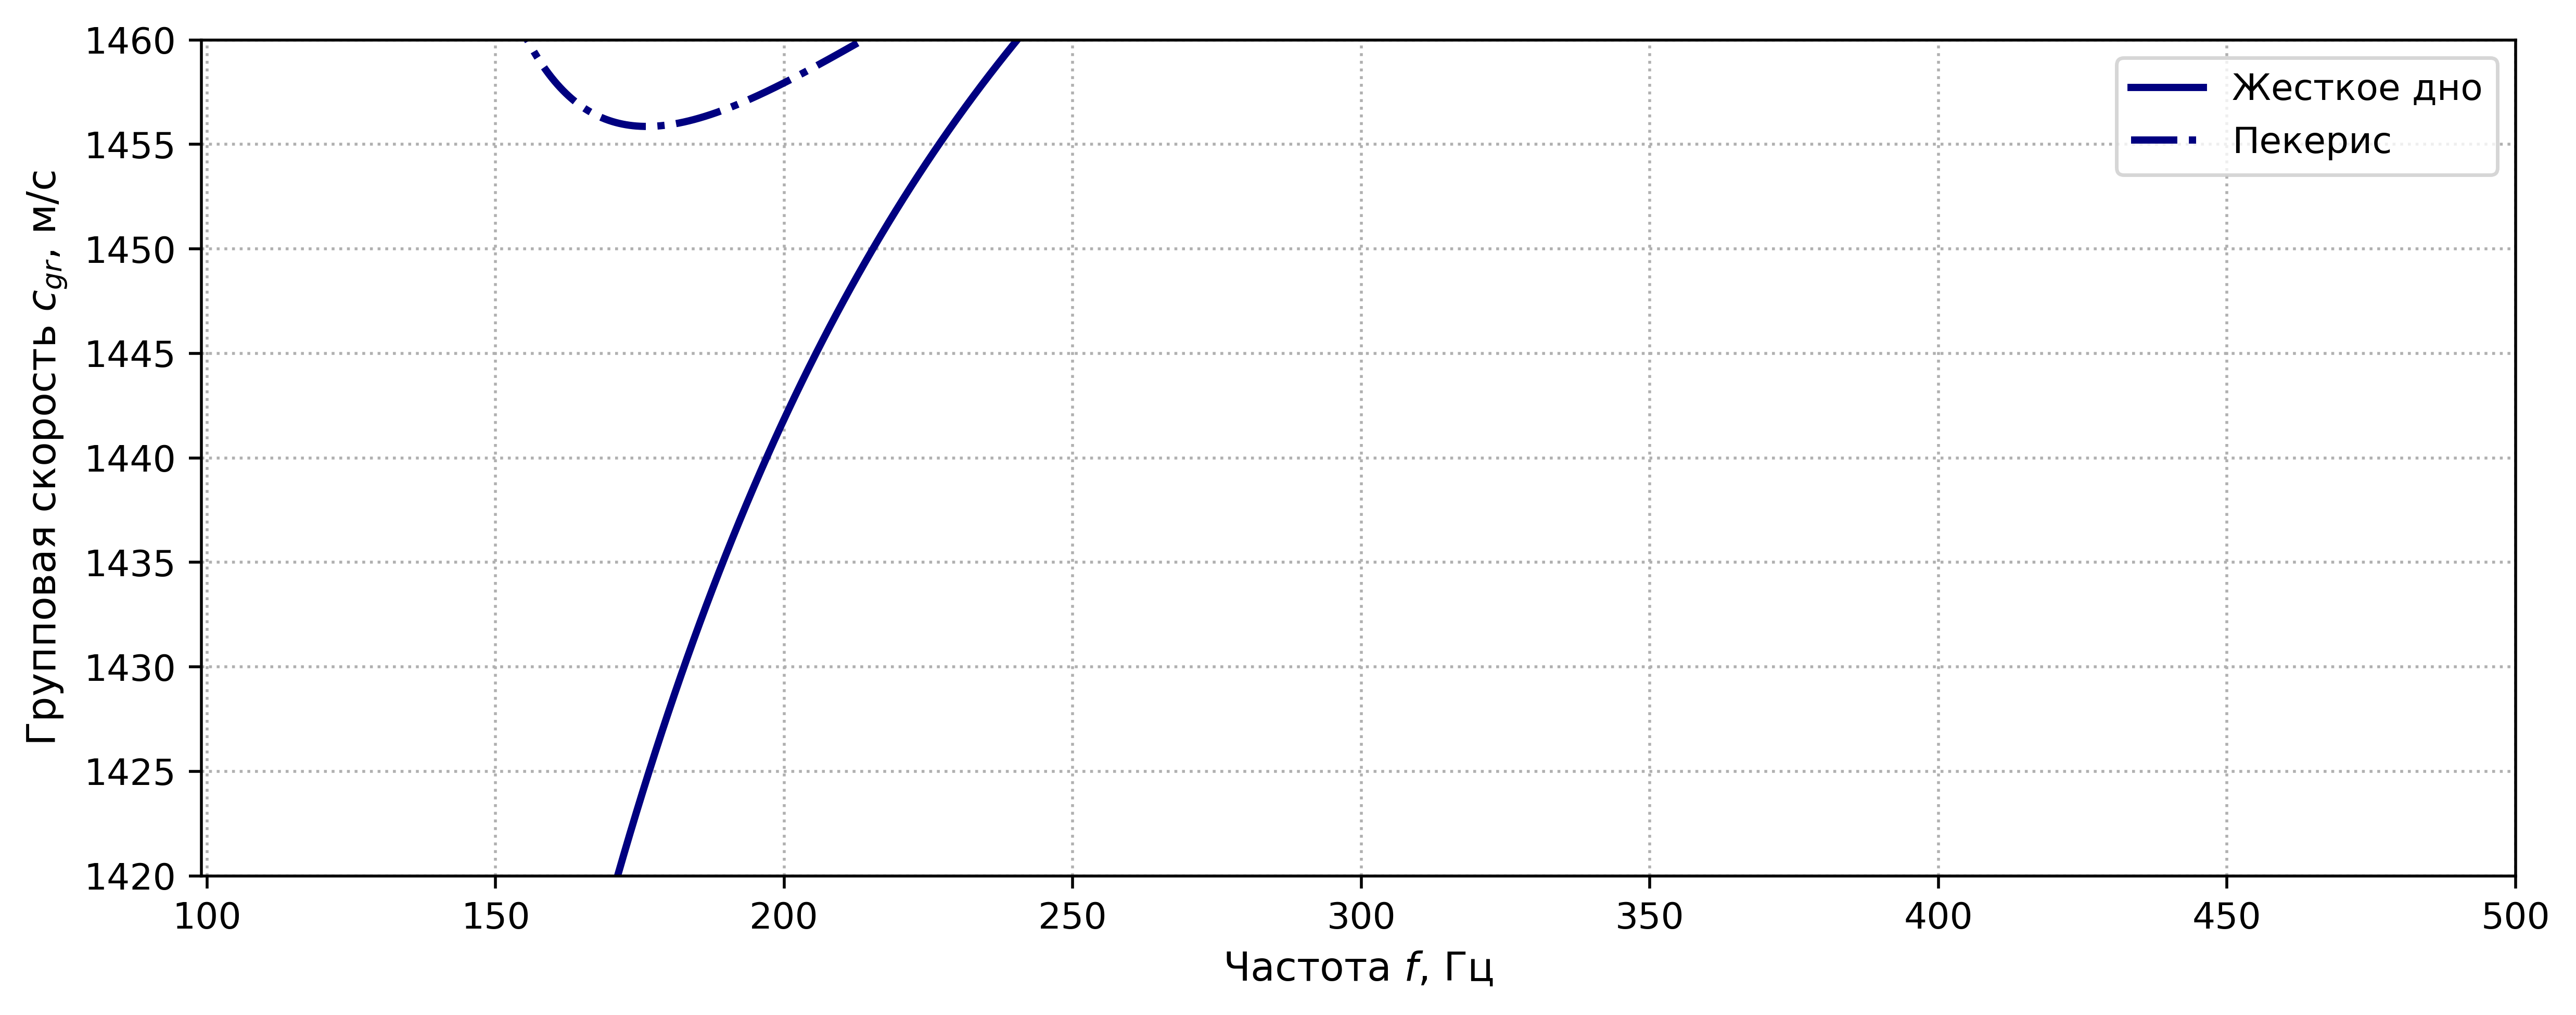

In [18]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import fmin
from matplotlib.lines import Line2D

# =============================================================================
# БЛОК НАСТРОЕК: ПАРАМЕТРЫ СРЕД И КОЛИЧЕСТВО МОД
# =============================================================================

IDEAL_CONFIG = {
    'modes': np.arange(1, 2),    # Номера мод
    'c': 1500.0,                  # Скорость звука в воде, м/с
    'H': 6.8,                     # Глубина волновода, м
    'fmin': 100.0,                  # Нижняя граница частоты, Гц
    'fmax': 1000.0,               # Верхняя граница частоты, Гц
    'df': 0.1                     # Шаг по частоте, Гц
}

PEKERIS_CONFIG = {
    'modes': np.arange(1, 2),     # Номера мод
    'c0': 1500.0,                 # Скорость звука в воде, м/с
    'c1': 1700.0,                 # Скорость звука в жидком дне, м/с
    'H': 6.8,                     # Толщина слоя воды, м
    'ro': 2.0,                    # Отношение плотностей дна и воды
    'fmin': 117.0,                # Нижняя граница частоты, Гц
    'fmax': 500.0,                # Верхняя граница частоты, Гц
    'df': 0.1                     # Шаг по частоте, Гц
}

# =============================================================================
# МАТЕМАТИЧЕСКИЕ ЯДРА МОДЕЛИРОВАНИЯ
# =============================================================================

def dispersion_ideal_bottom(m, c, f, H):
    f_safe = np.where(f == 0, np.nan, f)
    with np.errstate(invalid='ignore'):
        term_rigid = 1 - ((m - 0.5) * (c / (2 * f_safe * H)))**2
        term_soft = 1 - (m * (c / (2 * f_safe * H)))**2
        
        c_group_rigid = c * np.sqrt(np.where(term_rigid < 0, np.nan, term_rigid))
        c_group_soft = c * np.sqrt(np.where(term_soft < 0, np.nan, term_soft))
    
    c_phase_rigid = (c**2) / c_group_rigid
    c_phase_soft = (c**2) / c_group_soft
    return c_group_rigid, c_group_soft, c_phase_rigid, c_phase_soft


def esearch_half_space_function1(l, c0, c1, ro, f, h):
    k0 = 2 * np.pi * f / c0
    n = c0 / c1
    x0 = np.pi * l
    xx = np.linspace(x0 - np.pi/2, x0 + np.pi/2, int(1e5))
    fcut = c0 * (l - 0.5) / (2 * h * np.sqrt(1 - n**2))
    
    c_phase = np.zeros(len(f))
    for num_f in range(len(f)):
        if f[num_f] <= fcut:
            c_phase[num_f] = 0
            continue
            
        nu = k0[num_f] * h * np.sqrt(1 - n**2)
        my_func = lambda x: np.abs(ro * x + np.tan(x) * np.sqrt(nu**2 - x**2 + 0j))
        
        fx = my_func(xx)
        xx_min = xx[np.argmin(fx)]
        
        sol_res = fmin(my_func, xx_min, xtol=1e-13, ftol=1e-13, disp=False, full_output=True)
        sol = sol_res[0][0]
        
        if sol_res[4] != 0:
            c_phase[num_f] = 0
            continue
            
        psil = np.sqrt((k0[num_f] * h)**2 - sol**2) / h
        c_phase[num_f] = 2 * np.pi * f[num_f] / psil
    return c_phase

# =============================================================================
# МОДЕРНИЗИРОВАННЫЕ ФУНКЦИИ СИМУЛЯЦИЙ (ТЕПЕРЬ ВОЗВРАЩАЮТ ДАННЫЕ)
# =============================================================================

def run_ideal_bottom_simulation(cfg):
    freq = np.arange(cfg['fmin'], cfg['fmax'] + cfg['df'], cfg['df'])
    modes = cfg['modes']
    
    c_gr_rigid = np.zeros((len(modes), len(freq)))
    c_gr_soft = np.zeros_like(c_gr_rigid)
    c_ph_rigid = np.zeros_like(c_gr_rigid)
    c_ph_soft = np.zeros_like(c_gr_rigid)
    
    for idx, m in enumerate(modes):
        cg_r, cg_s, cp_r, cp_s = dispersion_ideal_bottom(m, cfg['c'], freq, cfg['H'])
        c_gr_rigid[idx, :] = cg_r
        c_gr_soft[idx, :] = cg_s
        c_ph_rigid[idx, :] = cp_r
        c_ph_soft[idx, :] = cp_s
        
    for arr in [c_gr_rigid, c_gr_soft, c_ph_rigid, c_ph_soft]:
        arr[arr < np.finfo(float).eps] = np.nan
        
    # Возвращаем частоты и массив групповых скоростей для жесткого дна
    return freq, c_gr_rigid


def run_pekeris_simulation(cfg):
    freq = np.arange(cfg['fmin'], cfg['fmax'] + cfg['df'], cfg['df'])
    omega = 2 * np.pi * freq
    modes = cfg['modes']
    
    c_phase = np.zeros((len(modes), len(freq)))
    c_gr = np.zeros_like(c_phase)
    d_omega = omega[1] - omega[0]
    
    for idx, m in enumerate(modes):
        print(f"Расчет моды волновода Пекериса № {m}...")
        c_phase[idx, :] = esearch_half_space_function1(m, cfg['c0'], cfg['c1'], cfg['ro'], freq, cfg['H'])
        c_phase_m = c_phase[idx, :]
        
        with np.errstate(divide='ignore', invalid='ignore'):
            grad_c_phase = np.gradient(c_phase_m, d_omega)
            c_gr_tmp = 1.0 / (1.0 / c_phase_m - (omega / (c_phase_m**2)) * grad_c_phase)
            c_gr[idx, c_phase_m != 0] = c_gr_tmp[c_phase_m != 0]
            
            max_val = np.max(c_phase_m)
            if max_val > 0:
                c_gr[idx, c_phase_m == max_val] = max_val
                
    c_phase[c_phase < np.finfo(float).eps] = np.nan
    c_gr[c_gr < np.finfo(float).eps] = np.nan
    
    # Возвращаем частоты и расчетный массив групповых скоростей Пекериса
    return freq, c_gr

# =============================================================================
# ФУНКЦИЯ СТРОИТЕЛЬСТВА СОВМЕСТНОГО ГРАФИКА ГРУППОВЫХ СКОРОСТЕЙ
# =============================================================================

def plot_joint_group_velocities(f_ideal, cg_ideal, f_pekeris, cg_pekeris, modes_ideal, modes_pekeris):
    """Строит на одном графике групповые скорости для обеих моделей."""
    plt.figure(figsize=(10, 4), dpi=500)
    
    # Используем качественную разную цветовую палитру для мод
    # Чтобы отличать модели, зафиксируем стиль: 
    # Идеальное жесткое дно — Сплошная линия (-), Волновод Пекериса — Штрих-пунктир (-.)
    
    max_modes = max(len(modes_ideal), len(modes_pekeris))
    colors = plt.cm.jet(np.linspace(0, 0.9, max_modes))
    
    # 1. Отрисовка кривых идеального жесткого дна
    for idx, m in enumerate(modes_ideal):
        plt.plot(f_ideal, cg_ideal[idx, :], linestyle='-', color=colors[idx], linewidth=2,
                 label=f'Жесткое дно')
        
    # 2. Отрисовка кривых волновода Пекериса
    for idx, m in enumerate(modes_pekeris):
        plt.plot(f_pekeris, cg_pekeris[idx, :], linestyle='-.', color=colors[idx], linewidth=2,
                 label=f'Пекерис')
        
    plt.ylabel('Групповая скорость $c_{gr}$, м/с', fontsize=11)
    plt.xlabel('Частота $f$, Гц', fontsize=11)
    
    
    # Ограничим отображение по оси X до fmax Пекериса (500 Гц), так как это область совместных данных
    plt.xlim(99, max(f_pekeris)) 
    plt.ylim(1000, 1700)
    plt.grid(True, linestyle=':')
    
    # Создаем кастомные элементы легенды для типов волноводов
    # model_types_legend = [
    #     Line2D([0], [0], color='black', linestyle='-', linewidth=2, label='Идеальное жесткое дно'),
    #     Line2D([0], [0], color='black', linestyle='-.', linewidth=2, label='Волновод Пекериса')
    # ]
    
    # Сборка легенды номеров мод и типов линий
    handles, labels = plt.gca().get_legend_handles_labels()
    plt.legend(handles=handles, loc='upper right', framealpha=0.8)
    plt.ylim(1420, 1460)
    plt.tight_layout()
    plt.show()

# =============================================================================
# ТОЧКА ВХОДА
# =============================================================================
if __name__ == '__main__':
    print("--- Расчет дисперсии: Идеальное жесткое дно ---")
    freq_id, cg_id = run_ideal_bottom_simulation(IDEAL_CONFIG)
    
    print("\n--- Расчет дисперсии: Волновод Пекериса ---")
    freq_pek, cg_pek = run_pekeris_simulation(PEKERIS_CONFIG)
    
    print("\n--- Визуализация совмещенного графика групповых скоростей ---")
    plot_joint_group_velocities(
        f_ideal=freq_id, 
        cg_ideal=cg_id, 
        f_pekeris=freq_pek, 
        cg_pekeris=cg_pek, 
        modes_ideal=IDEAL_CONFIG['modes'], 
        modes_pekeris=PEKERIS_CONFIG['modes']
    )